# Data Cleaning & Visualization Project**Dataset:** Titanic Passenger DataThis notebook loads a raw Titanic dataset, cleans it (missing values, duplicates, outliers), and visualizes key insights.

## 1. Load the Data

In [1]:
import pandas as pdimport matplotlib.pyplot as pltimport seaborn as snsimport numpy as npdf = pd.read_csv('tested__1_.csv')df.head()

   PassengerId  Survived  Pclass  ...0          892         0       3  ...1          893         1       3  ...

## 2. Check for Missing Values

In [1]:
df.isnull().sum()

PassengerId      0Survived         0Pclass           0Name             0Sex              0Age             86SibSp            0Parch            0Ticket           0Fare             1Cabin          327Embarked         0dtype: int64

**Finding:** `Age` has 86 missing values, `Fare` has 1, and `Cabin` has 327 missing (most of the column). We'll handle each appropriately below.

## 3. Handle Missing Values

In [1]:
df_clean = df.copy()# Fill numeric columns with median (robust to outliers)df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())# Fill categorical column with the most common valuedf_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])# Cabin has too many missing values to fill meaningfully -> mark as 'Unknown'df_clean['Cabin'] = df_clean['Cabin'].fillna('Unknown')df_clean.isnull().sum()

PassengerId    0Survived       0Pclass         0Name           0Sex            0Age            0SibSp          0Parch          0Ticket         0Fare           0Cabin          0Embarked       0dtype: int64

## 4. Remove Duplicates

In [1]:
before = df_clean.shape[0]df_clean = df_clean.drop_duplicates()after = df_clean.shape[0]print(f"Removed {before-after} duplicate rows. Remaining rows: {after}")

Removed 0 duplicate rows. Remaining rows: 418

## 5. Handle Outliers (Fare) using IQR method

In [1]:
Q1 = df_clean['Fare'].quantile(0.25)Q3 = df_clean['Fare'].quantile(0.75)IQR = Q3 - Q1lower = Q1 - 1.5 * IQRupper = Q3 + 1.5 * IQRbefore = df_clean.shape[0]df_clean = df_clean[(df_clean['Fare'] >= lower) & (df_clean['Fare'] <= upper)]after = df_clean.shape[0]print(f"Removed {before-after} Fare outliers. Remaining rows: {after}")

Removed 55 Fare outliers. Remaining rows: 363

## 6. Save Cleaned Data

In [1]:
df_clean.to_csv('titanic_cleaned.csv', index=False)print("Cleaned dataset saved as titanic_cleaned.csv")

Cleaned dataset saved as titanic_cleaned.csv

## 7. Visualization: Age Distribution

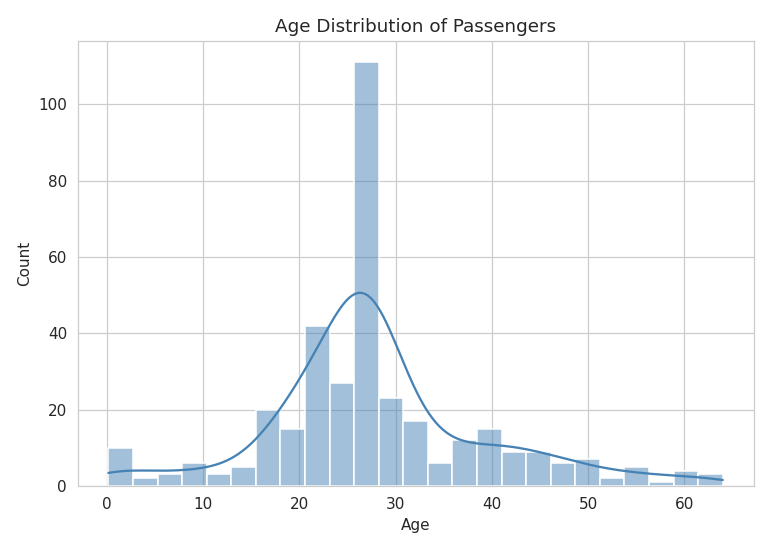

In [1]:
plt.figure(figsize=(7,5))sns.histplot(df_clean['Age'], bins=25, kde=True, color='steelblue')plt.title('Age Distribution of Passengers')plt.xlabel('Age'); plt.ylabel('Count')plt.show()

**Insight:** Most passengers were between 20-40 years old, with a smaller number of children and elderly passengers.

## 8. Visualization: Survival Count

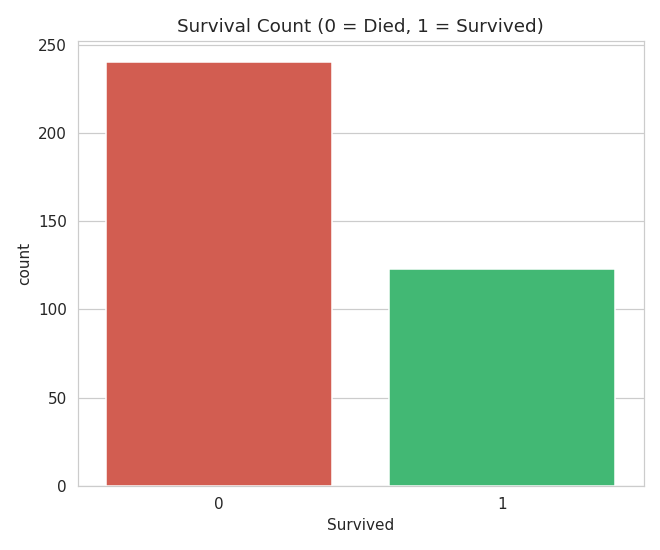

In [1]:
plt.figure(figsize=(6,5))sns.countplot(x='Survived', hue='Survived', data=df_clean, palette=['#e74c3c','#2ecc71'], legend=False)plt.title('Survival Count (0 = Died, 1 = Survived)')plt.show()

**Insight:** More passengers did not survive than those who did, consistent with the historical Titanic disaster.

## 9. Visualization: Fare by Passenger Class

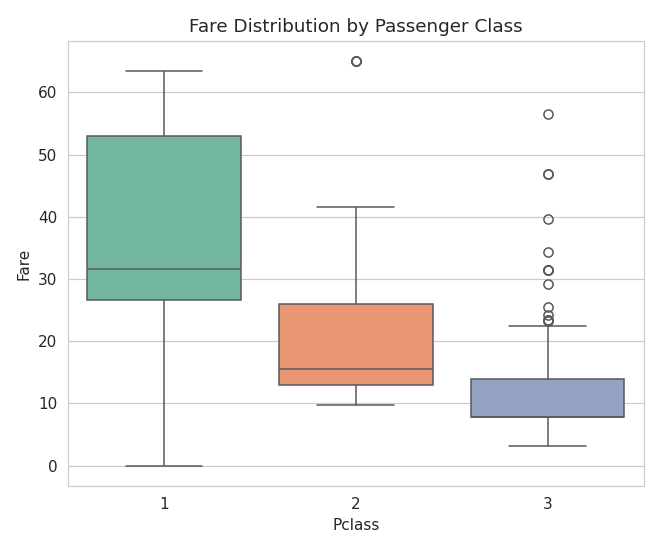

In [1]:
plt.figure(figsize=(6,5))sns.boxplot(x='Pclass', y='Fare', hue='Pclass', data=df_clean, palette='Set2', legend=False)plt.title('Fare Distribution by Passenger Class')plt.show()

**Insight:** 1st class passengers paid noticeably higher fares than 2nd and 3rd class, as expected.

## 10. Visualization: Correlation Heatmap

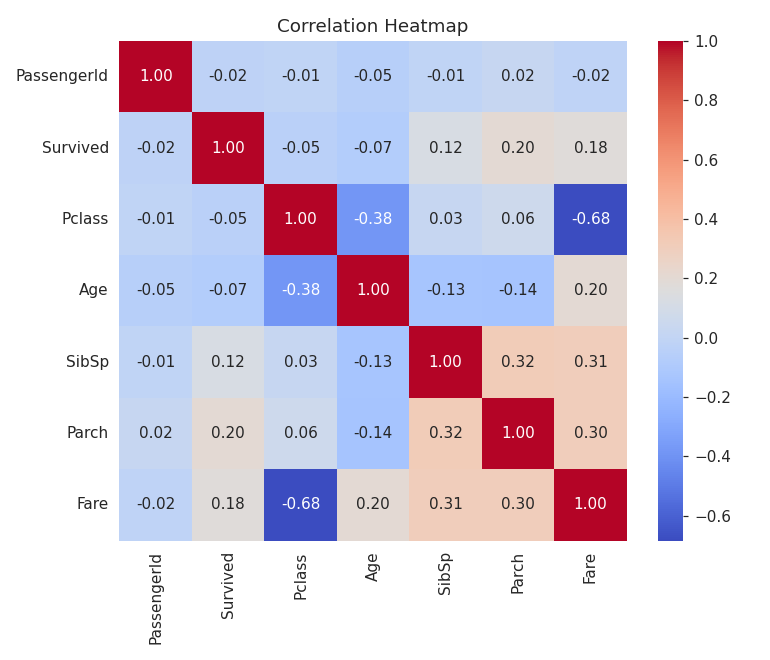

In [1]:
plt.figure(figsize=(7,6))corr = df_clean.select_dtypes(include=[np.number]).corr()sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')plt.title('Correlation Heatmap')plt.show()

**Insight:** `Pclass` and `Fare` show a negative correlation, meaning lower class numbers (1st class) paid higher fares. `Survived` correlates weakly with `Fare` and `Pclass`.

## 11. Visualization: Survival by Gender

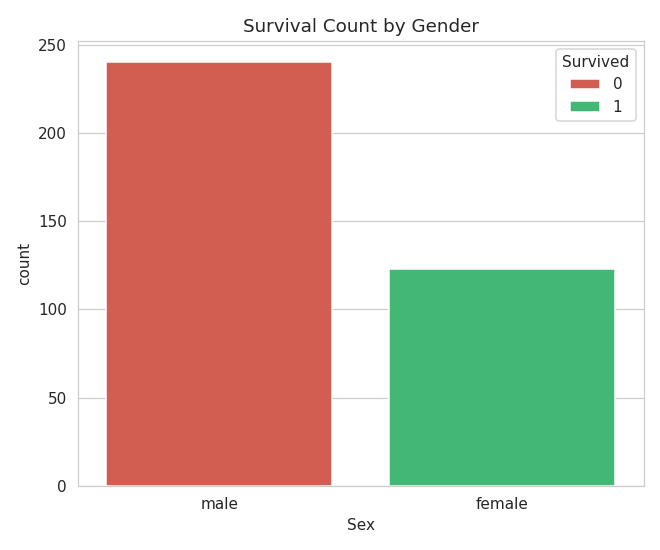

In [1]:
plt.figure(figsize=(6,5))sns.countplot(x='Sex', hue='Survived', data=df_clean, palette=['#e74c3c','#2ecc71'])plt.title('Survival Count by Gender')plt.show()

**Insight:** Female passengers had a noticeably higher survival rate than male passengers, reflecting the 'women and children first' evacuation policy.

## 12. Summary / Storytelling- The dataset had missing values in `Age`, `Fare`, and `Cabin` — these were filled using median/mode imputation, and `Cabin` was marked as 'Unknown' where missing.- 55 outlier rows in `Fare` were removed using the IQR method to avoid skewing the analysis.- Most passengers were aged 20-40.- Survival rate was higher for women than men, and higher for 1st class passengers than 3rd class — showing that both **gender** and **socio-economic class** influenced survival chances on the Titanic.**Tools used:** Python, Pandas, Matplotlib, Seaborn